In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
import joblib

In [34]:
df_true = pd.read_csv("../True.csv")
df_fake = pd.read_csv("../Fake.csv")

In [35]:
df_true

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [36]:
df_fake

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [37]:
df_true['label'] = 1
df_fake['label'] = 0

In [38]:
df_main = pd.concat([df_true, df_fake], ignore_index=True)
df_main = df_main.sample(frac=1,random_state=42).reset_index(drop=True)

In [39]:
df_main

,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0
...,...,...,...,...,...
44893,Nigeria says U.S. agrees delayed $593 million ...,ABUJA (Reuters) - The United States has formal...,worldnews,"December 27, 2017",1
44894,Boiler Room #62 – Fatal Illusions,Tune in to the Alternate Current Radio Network...,Middle-east,"June 29, 2016",0
44895,ATHEISTS SUE GOVERNOR OF TEXAS Over Display on...,I m convinced the Freedom From Religion group...,Government News,"Feb 27, 2016",0
44896,Republican tax plan would deal financial hit t...,WASHINGTON (Reuters) - The Republican tax plan...,politicsNews,"November 2, 2017",1


In [40]:
df_main["subject"].unique()

array(['News', 'politicsNews', 'politics', 'worldnews', 'Government News',
       'left-news', 'Middle-east', 'US_News'], dtype=object)

In [41]:
df_main = df_main.drop(columns = ["subject", "date"])

In [42]:
df_main

,title,text,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,0
...,...,...,...
44893,Nigeria says U.S. agrees delayed $593 million ...,ABUJA (Reuters) - The United States has formal...,1
44894,Boiler Room #62 – Fatal Illusions,Tune in to the Alternate Current Radio Network...,0
44895,ATHEISTS SUE GOVERNOR OF TEXAS Over Display on...,I m convinced the Freedom From Religion group...,0
44896,Republican tax plan would deal financial hit t...,WASHINGTON (Reuters) - The Republican tax plan...,1


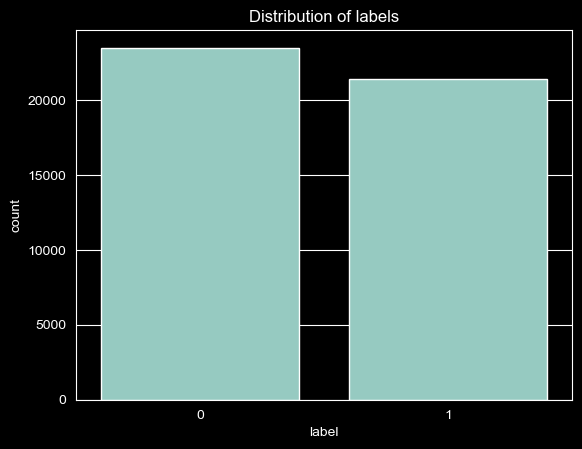

In [43]:
sns.countplot(x="label", data=df_main)
plt.title("Distribution of labels")
plt.show()

In [44]:
def to_lower(dataframe,column):
    dataframe[column] = dataframe[column].str.lower()
    return dataframe

In [45]:
def remove_html(dataframe, column):
    dataframe[column] = dataframe[column].apply(lambda x: re.sub('<.*?>', ' ', x))
    return dataframe

In [46]:
def remove_punctuation(dataframe, column):
    dataframe[column] = dataframe[column].apply(lambda x: re.sub('[^a-zA-Z]', ' ', x))
    return dataframe

In [47]:
def tokenization(dataframe,column):
    dataframe[column] = dataframe[column].apply(lambda x: word_tokenize(x))
    return dataframe

In [48]:
def remove_stopwords(dataframe,column):
    stop_words = stopwords.words('english')
    dataframe[column] = dataframe[column].apply(lambda x:[word for word in x if word not in stop_words])
    return dataframe

In [49]:
def steming(dataframe,column):
    porter = PorterStemmer()
    dataframe[column] = dataframe[column].apply(lambda x: [porter.stem(word) for word in x])
    return dataframe

In [50]:
def list_to_string(dataframe,column):
    dataframe[column] = dataframe[column].apply(lambda x: " ".join(x))
    return dataframe

In [51]:
#Function pipeline
function_pipeline = {
    "to_lower": to_lower,
    "remove_html": remove_html,
    "remove_punctuation": remove_punctuation,
    "tokenization": tokenization,
    "remove_stopwords": remove_stopwords,
    "steming": steming,
    "list_to_string": list_to_string
}

In [52]:
df_main['content'] = df_main['title'] + ' ' + df_main['text']

In [53]:
#Aplly function pipeline to the title column
dataframe = df_main

for name,func in function_pipeline.items():
    print(f"Applying {name} function")
    startTime = time.time()
    dataframe = func(dataframe, "content")
    endTime = time.time()
    print(f"Time taken to apply {name} function: {endTime - startTime:.2f} seconds")

Applying to_lower function
Time taken to apply to_lower function: 0.28 seconds
Applying remove_html function
Time taken to apply remove_html function: 0.08 seconds
Applying remove_punctuation function
Time taken to apply remove_punctuation function: 3.17 seconds
Applying tokenization function
Time taken to apply tokenization function: 44.80 seconds
Applying remove_stopwords function
Time taken to apply remove_stopwords function: 33.09 seconds
Applying steming function
Time taken to apply steming function: 180.70 seconds
Applying list_to_string function
Time taken to apply list_to_string function: 0.54 seconds


In [55]:
df_main = df_main.drop(columns = ["title", "text"])

In [56]:
df_main

,label,content
0,0,break gop chairman grassley enough demand trum...
1,0,fail gop candid rememb hilari mock eulog video...
2,0,mike penc new dc neighbor hilari troll homopho...
3,1,california ag pledg defend birth control insur...
4,0,az rancher live us mexico border destroy nanci...
...,...,...
44893,1,nigeria say u agre delay million fighter plane...
44894,0,boiler room fatal illus tune altern current ra...
44895,0,atheist sue governor texa display capitol grou...
44896,1,republican tax plan would deal financi hit u u...


In [61]:
X = df_main["content"]
y = df_main["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
#sklearn pipeline
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}
for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', model)
    ])
    print("====================================")
    print(f"Training {name} model...")
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    end_time = time.time()

    duration = end_time - start_time
    print(f"{name}: {score:.4f} | Duration: {duration:.2f} seconds")
    print("=====================================")

Training Random Forest model...
Random Forest: 0.9911 | Duration: 88.94 seconds
Training Logistic Regression model...
Logistic Regression: 0.9872 | Duration: 5.66 seconds
Training Naive Bayes model...
Naive Bayes: 0.9343 | Duration: 5.24 seconds
Training SVM model...
SVM: 0.9951 | Duration: 5.60 seconds


In [63]:
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LinearSVC())
])

pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])

pipeline_svm.fit(X_train, y_train)
pipeline_lr.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [64]:
joblib.dump(pipeline_svm, 'svm.pkl')
joblib.dump(pipeline_lr, 'logistic_regression.pkl')

print("Models saved!")

Models saved!
